<a href="https://colab.research.google.com/github/Sohail-Azmath/Basic-grocery-Management-System/blob/main/MajorProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import statsmodels.api as sm
from itertools import product
from math import sqrt
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

colors = ["windows blue", "amber", "faded green", "dusty purple"]
sns.set(rc={"figure.figsize": (20,10), "axes.titlesize" : 18, "axes.labelsize" : 12,
            "xtick.labelsize" : 14, "ytick.labelsize" : 14 })

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessevent/all-crypto-currencies")

print("Path to dataset files:", path)

100%|██████████| 22.5M/22.5M [00:00<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessevent/all-crypto-currencies/versions/17


In [ ]:
df = pd.read_csv('/root/.cache/kagglehub/datasets/jessevent/all-crypto-currencies/versions/17/crypto-markets.csv')
print(df.columns)


Index(['slug', 'symbol', 'name', 'date', 'ranknow', 'open', 'high', 'low',
       'close', 'volume', 'market', 'close_ratio', 'spread'],
      dtype='object')


In [ ]:
dateparse = lambda dates: pd.to_datetime(dates, format='%Y-%m-%d')
df = pd.read_csv('/root/.cache/kagglehub/datasets/jessevent/all-crypto-currencies/versions/17/crypto-markets.csv', parse_dates=['date'], index_col='date', date_parser=dateparse)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]


In [ ]:
df.sample(5)

,slug,symbol,name,ranknow,open,high,low,close,volume,market,close_ratio,spread
date,,,,,,,,,,,,
2018-02-17,tracto,TRCT,Tracto,1368,0.415409,0.519618,0.400483,0.426162,24316.0,6.794571e+06,0.2155,0.12
2018-06-16,monero,XMR,Monero,11,121.750000,128.230000,121.680000,126.830000,31221300.0,2.046743e+09,0.7863,6.55
2017-05-06,darcrus,DAR,Darcrus,1281,0.335493,0.401283,0.326704,0.401283,73948.0,5.468948e+06,1.0000,0.07
2016-08-13,terracoin,TRC,Terracoin,895,0.002541,0.002737,0.002526,0.002527,25.0,4.079000e+04,0.0047,0.00
2016-06-26,foldingcoin,FLDC,FoldingCoin,725,0.000182,0.000183,0.000163,0.000164,40.0,5.773900e+04,0.0500,0.00


In [ ]:
# Extract the bitcoin data only
btc=df[df['symbol']=='BTC']
# Drop some columns
btc.drop(['volume', 'market'],axis=1,inplace=True)

In [ ]:
# Lets take just the last year
#btc = btc.loc['2017']
#btc.shape

In [ ]:
# Check the data types of the columns
print(btc.dtypes)

# Optionally, check for non-numeric columns
print(btc.select_dtypes(exclude='number').columns)


slug            object
symbol          object
name            object
ranknow          int64
open           float64
high           float64
low            float64
close          float64
close_ratio    float64
spread         float64
dtype: object
Index(['slug', 'symbol', 'name'], dtype='object')


In [ ]:
# Drop non-numeric columns before resampling
btc_numeric = btc.select_dtypes(include='number')
btc_month = btc_numeric.resample('M').mean()


Dickey–Fuller test: p=0.479017


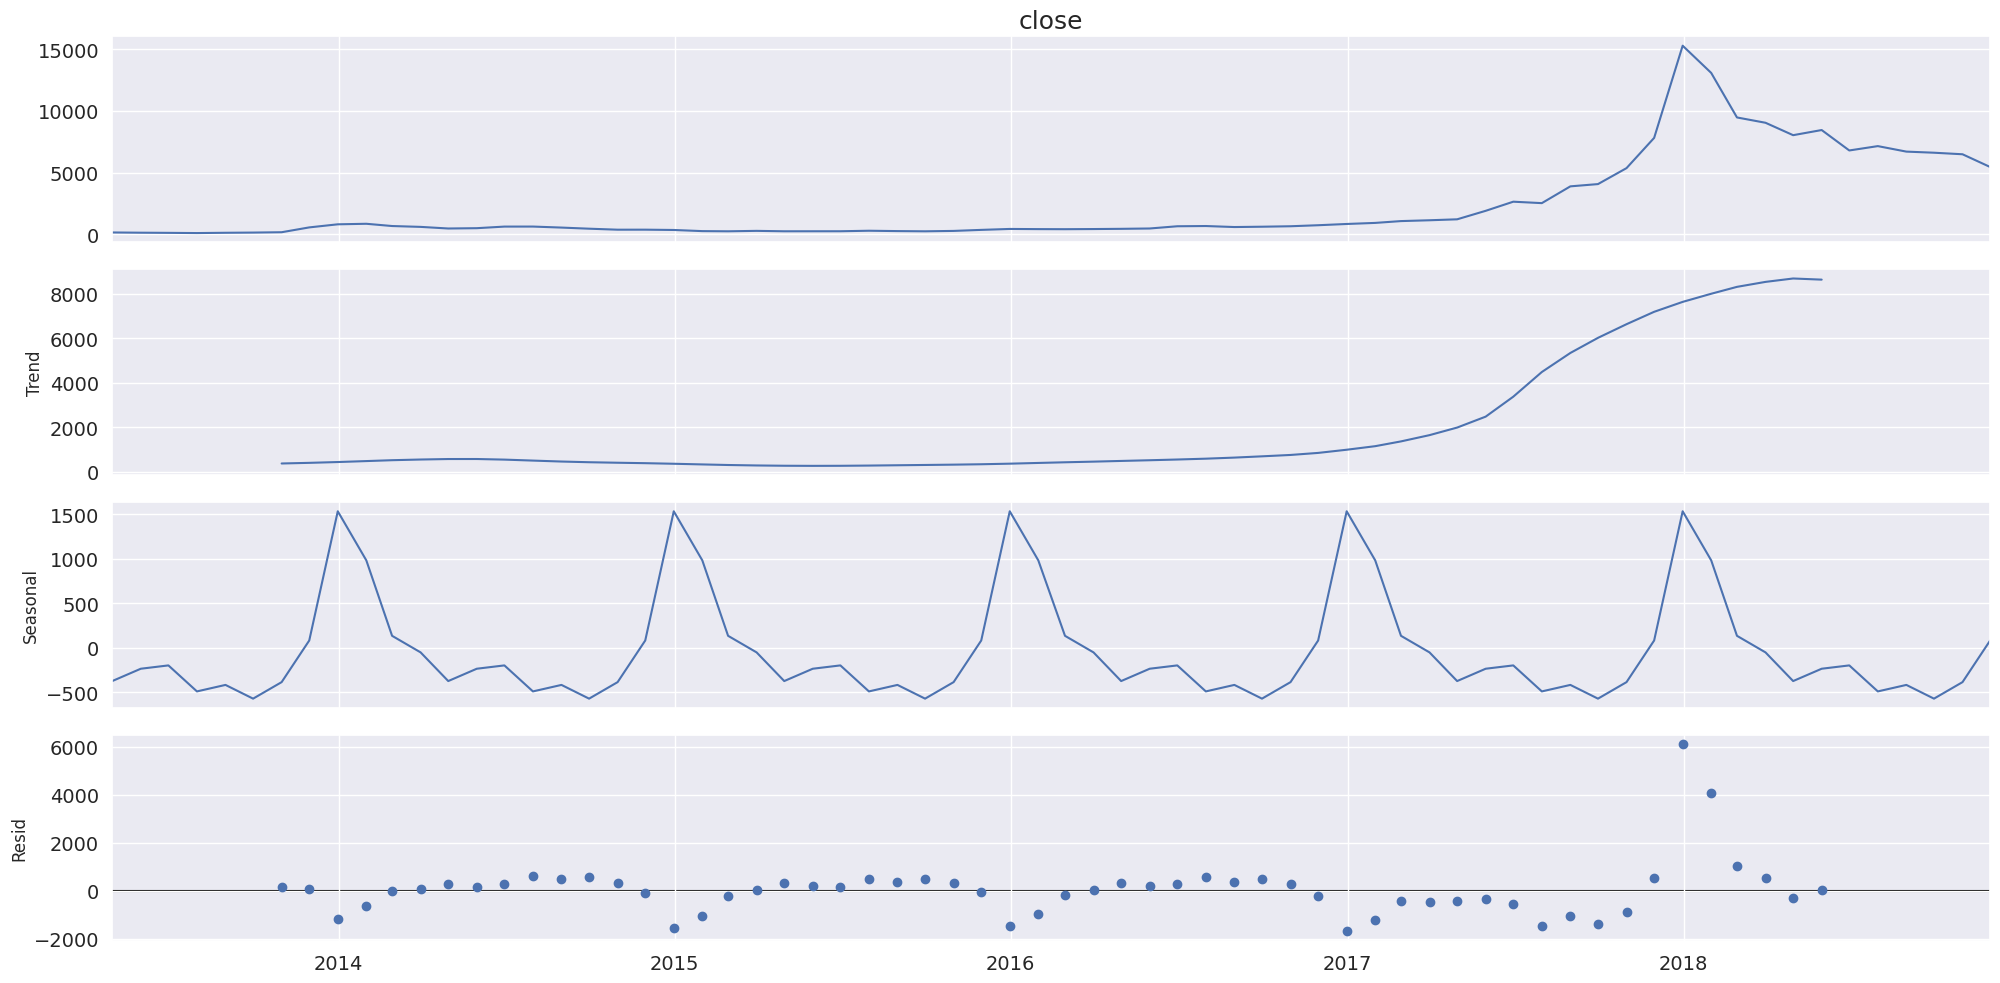

In [ ]:
#seasonal_decompose(btc_month.close, freq=12).plot()
seasonal_decompose(btc_month.close, model='additive').plot() # Changed btc_month.Close to btc_month.close
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.close)[1]) # Changed btc_month.Close to btc_month.close


In [ ]:
print(btc_month.columns)


Index(['ranknow', 'open', 'high', 'low', 'close', 'close_ratio', 'spread'], dtype='object')


In [ ]:
btc_month.columns = btc_month.columns.str.strip()  # Strip spaces


In [ ]:
# Box-Cox Transformation
btc_month['close_box'], lmbda = stats.boxcox(btc_month['close'])
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.close_box)[1])


Dickey–Fuller test: p=0.479048


In [ ]:
# Seasonal differentiation (12 months)
btc_month['box_diff_seasonal_12'] = btc_month.close_box - btc_month.close_box.shift(12)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff_seasonal_12[12:])[1])

Dickey–Fuller test: p=0.055750


In [ ]:
# Seasonal differentiation (3 months)
btc_month['box_diff_seasonal_3'] = btc_month.close_box - btc_month.close_box.shift(3)
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff_seasonal_3[3:])[1])

Dickey–Fuller test: p=0.013221


Dickey–Fuller test: p=0.025730


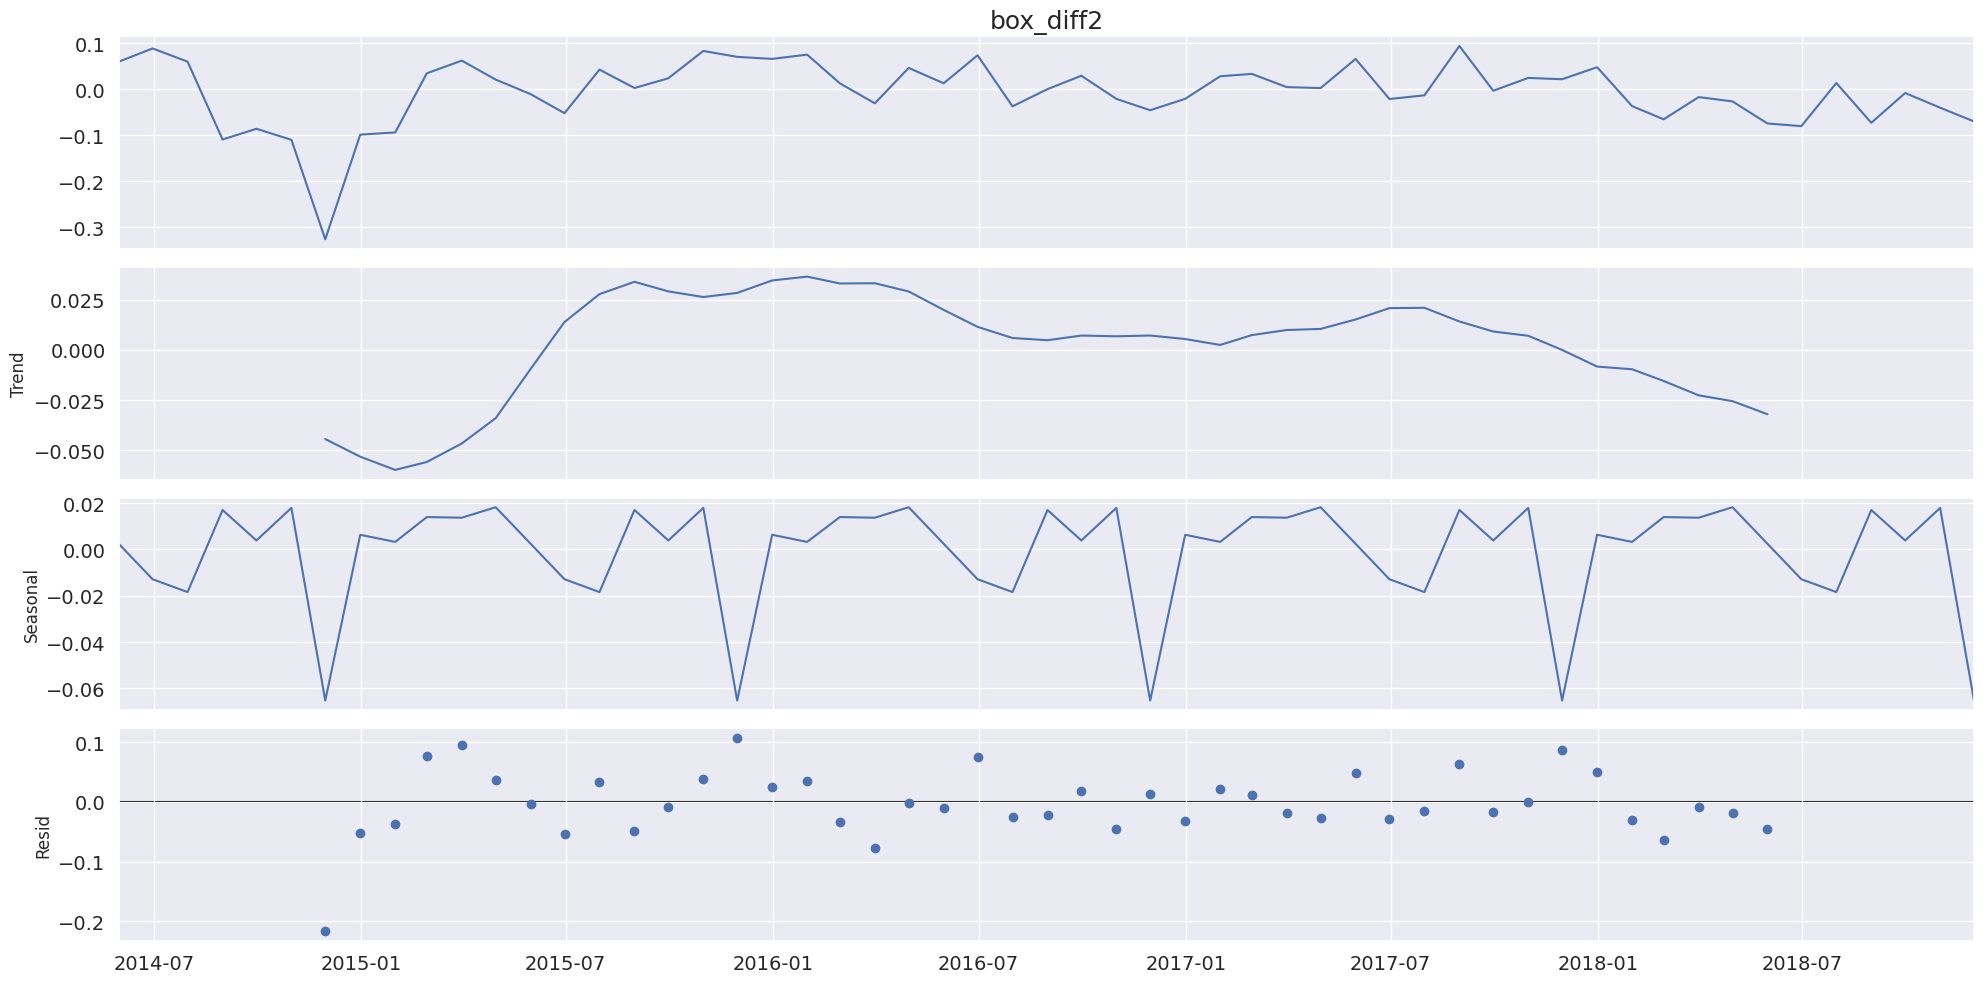

In [ ]:
# Regular differentiation
btc_month['box_diff2'] = btc_month.box_diff_seasonal_12 - btc_month.box_diff_seasonal_12.shift(1)

# STL-decomposition
seasonal_decompose(btc_month.box_diff2[13:]).plot()
print("Dickey–Fuller test: p=%f" % adfuller(btc_month.box_diff2[13:])[1])

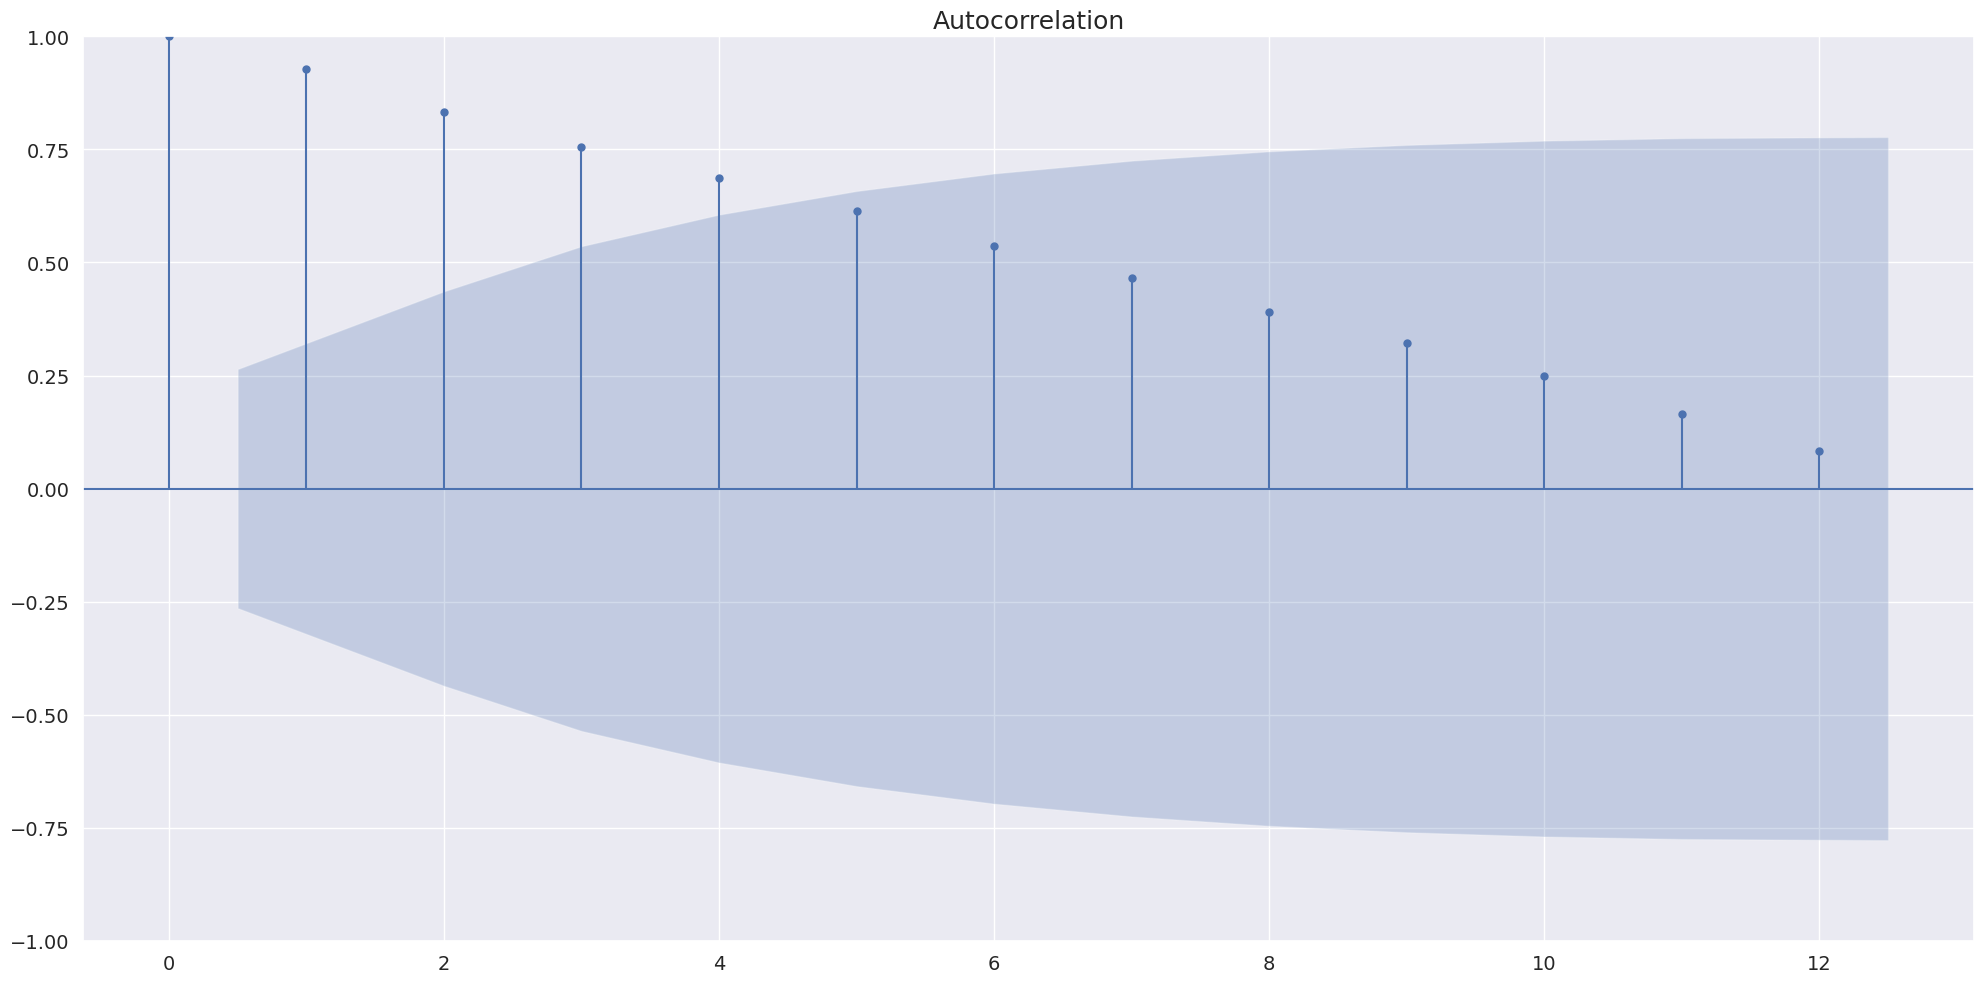

In [ ]:
#autocorrelation_plot(btc_month.close)
plot_acf(btc_month['close'][13:].values.squeeze(), lags=12)
plt.tight_layout()


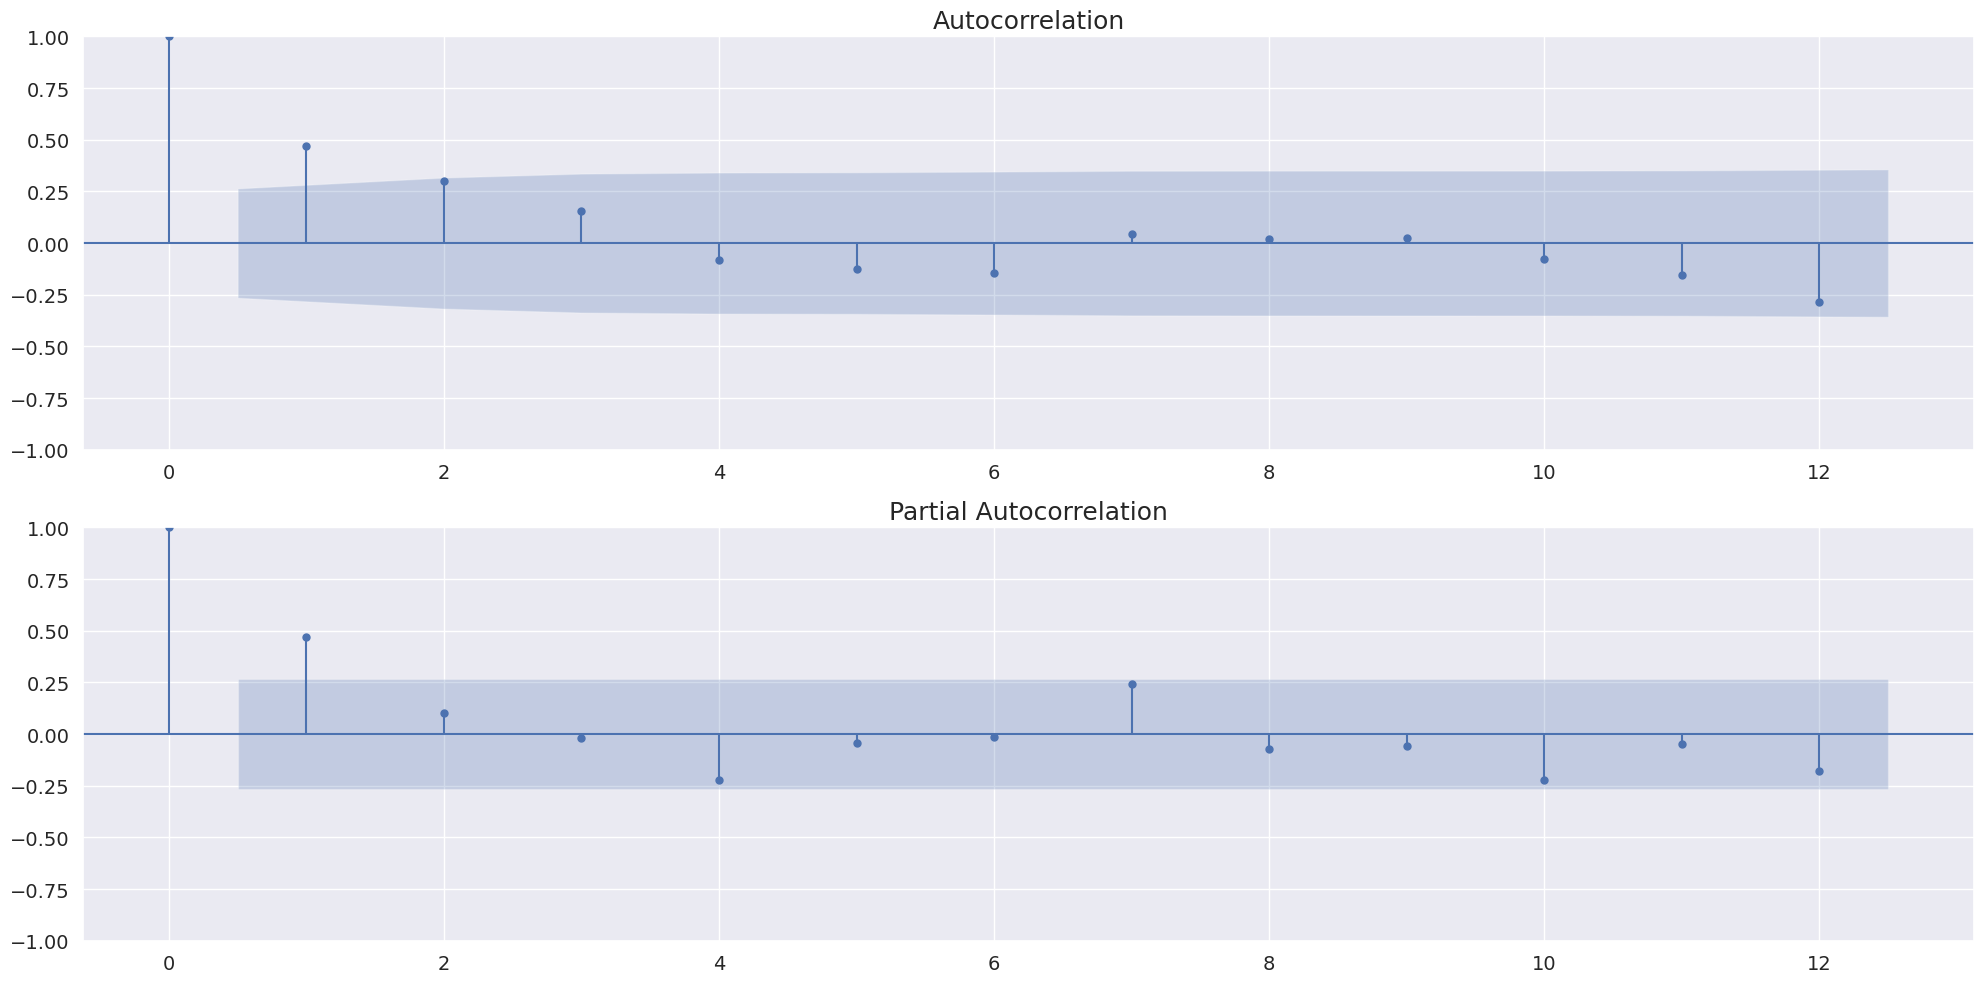

In [ ]:
# Initial approximation of parameters using Autocorrelation and Partial Autocorrelation Plots
ax = plt.subplot(211)
# Plot the autocorrelation function
#sm.graphics.tsa.plot_acf(btc_month.box_diff2[13:].values.squeeze(), lags=48, ax=ax)
plot_acf(btc_month.box_diff2[13:].values.squeeze(), lags=12, ax=ax)
ax = plt.subplot(212)
#sm.graphics.tsa.plot_pacf(btc_month.box_diff2[13:].values.squeeze(), lags=48, ax=ax)
plot_pacf(btc_month.box_diff2[13:].values.squeeze(), lags=12, ax=ax)
plt.tight_layout()

In [ ]:
# Initial approximation of parameters
qs = range(0, 3)
ps = range(0, 3)
d=1
parameters = product(ps, qs)
parameters_list = list(parameters)
len(parameters_list)

# Model Selection
results = []
best_aic = float("inf")
warnings.filterwarnings('ignore')
for param in parameters_list:
    try:
        model = SARIMAX(btc_month.close_box, order=(param[0], d, param[1])).fit(disp=-1)
    except ValueError:
        print('bad parameter combination:', param)
        continue
    aic = model.aic
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])

In [ ]:
# Best Models
result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())

  parameters         aic
3     (1, 0) -203.741371
1     (0, 1) -203.172631
4     (1, 1) -201.779360
6     (2, 0) -201.772454
2     (0, 2) -201.511396


In [ ]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:              close_box   No. Observations:                   68
Model:               SARIMAX(1, 1, 0)   Log Likelihood                 103.871
Date:                Tue, 29 Apr 2025   AIC                           -203.741
Time:                        18:07:48   BIC                           -199.332
Sample:                    04-30-2013   HQIC                          -201.997
                         - 11-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3750      0.149      2.524      0.012       0.084       0.666
sigma2         0.0026      0.000     12.206      0.000       0.002       0.003
Ljung-Box (L1) (Q):                   0.01   Jarque-

In [ ]:
print("Dickey–Fuller test:: p=%f" % adfuller(best_model.resid[13:])[1])

Dickey–Fuller test:: p=0.000000


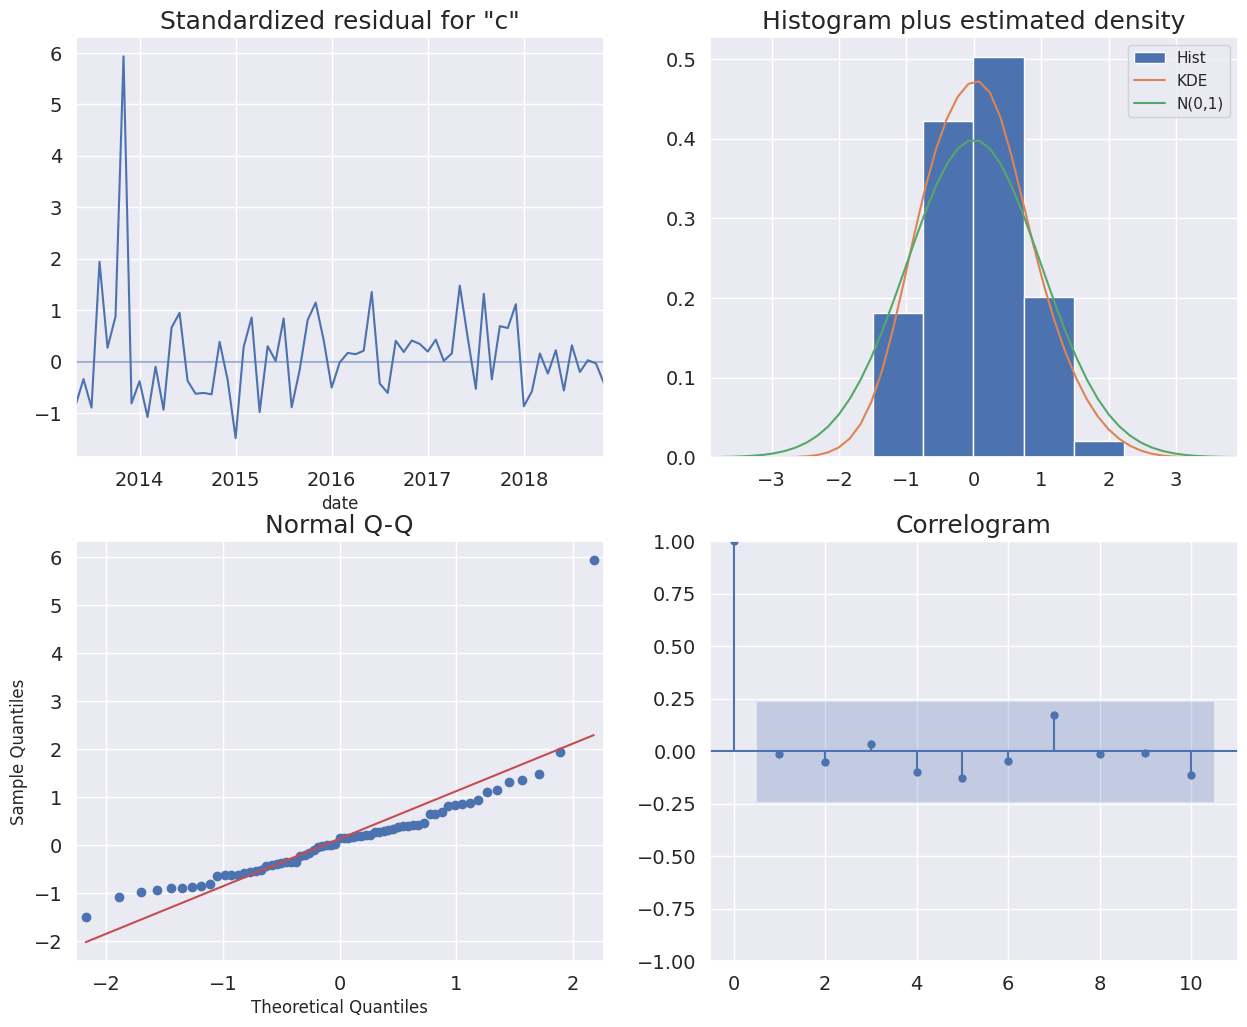

In [ ]:
best_model.plot_diagnostics(figsize=(15, 12))
plt.show()

In [ ]:
# Inverse Box-Cox Transformation Function
def invboxcox(y,lmbda):
   if lmbda == 0:
      return(np.exp(y))
   else:
      return(np.exp(np.log(lmbda*y+1)/lmbda))

Text(0, 0.5, 'USD')

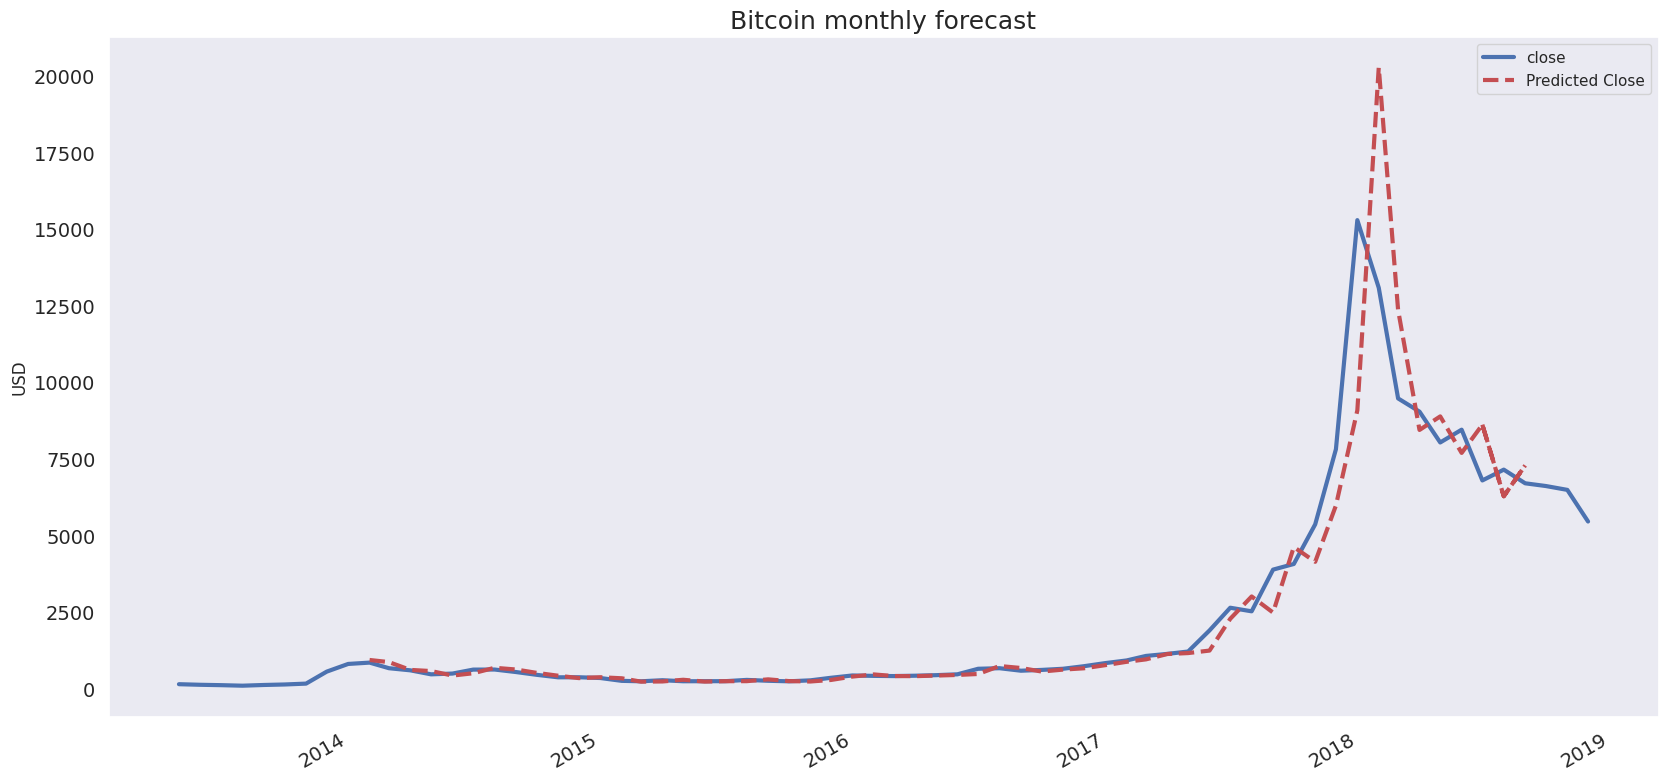

In [ ]:
# Prediction
btc_month_pred = btc_month[['close']]
date_list = [datetime(2018, 6, 30), datetime(2018, 7, 31), datetime(2018, 8, 31)]
future = pd.DataFrame(index=date_list, columns= btc_month.columns)
btc_month_pred = pd.concat([btc_month_pred, future])

#btc_month_pred['forecast'] = invboxcox(best_model.predict(start=0, end=75), lmbda)
btc_month_pred['forecast'] = invboxcox(best_model.predict(start=datetime(2014, 1, 31), end=datetime(2018, 8, 31)), lmbda)

btc_month_pred.close.plot(linewidth=3)
btc_month_pred.forecast.plot(color='r', ls='--', label='Predicted Close', linewidth=3)
plt.legend()
plt.grid()
plt.title('Bitcoin monthly forecast')
plt.ylabel('USD')

In [ ]:
# Initial approximation of parameters
Qs = range(0, 2)
qs = range(0, 3)
Ps = range(0, 3)
ps = range(0, 3)
D=1
d=1
parameters = product(ps, qs, Ps, Qs)
parameters_list = list(parameters)
len(parameters_list)

# Model Selection
results = []
best_aic = float("inf")
warnings.filterwarnings('ignore')
for param in parameters_list:
    try:
#        model = SARIMAX(btc_month.close_box, order=(param[0], d, param[1]), seasonal_order=(param[2], D, param[3], 12)).fit(disp=-1)
        model = SARIMAX(btc_month.close_box, order=(param[0], d, param[1]), seasonal_order=(param[2], D, param[3], 4)).fit(disp=-1)
    except ValueError:
        print('bad parameter combination:', param)
        continue
    aic = model.aic
    if aic < best_aic:
        best_model = model
        best_aic = aic
        best_param = param
    results.append([param, model.aic])

In [ ]:
# Best Models
result_table = pd.DataFrame(results)
result_table.columns = ['parameters', 'aic']
print(result_table.sort_values(by = 'aic', ascending=True).head())
print(best_model.summary())

      parameters         aic
19  (1, 0, 0, 1) -178.468761
21  (1, 0, 1, 1) -178.222109
7   (0, 1, 0, 1) -177.803918
9   (0, 1, 1, 1) -177.073976
23  (1, 0, 2, 1) -176.967073
                                      SARIMAX Results                                      
Dep. Variable:                           close_box   No. Observations:                   68
Model:             SARIMAX(1, 1, 0)x(0, 1, [1], 4)   Log Likelihood                  92.234
Date:                             Tue, 29 Apr 2025   AIC                           -178.469
Time:                                     18:09:24   BIC                           -172.039
Sample:                                 04-30-2013   HQIC                          -175.940
                                      - 11-30-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------

In [ ]:
print("Dickey–Fuller test:: p=%f" % adfuller(best_model.resid[13:])[1])

Dickey–Fuller test:: p=0.000000


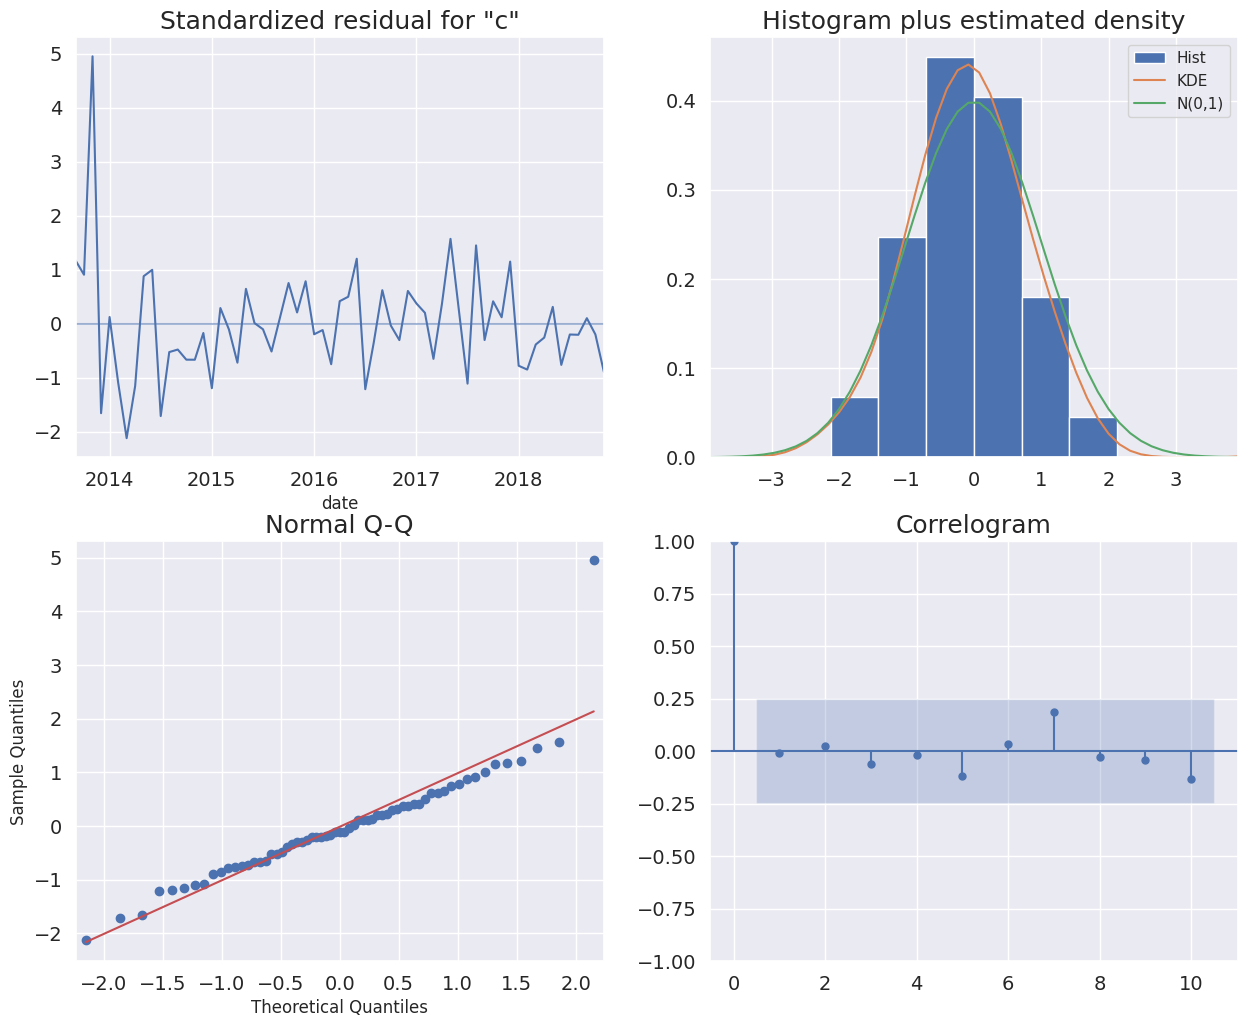

In [ ]:
best_model.plot_diagnostics(figsize=(15, 12))
plt.show()

Dickey–Fuller test:: p=0.000000


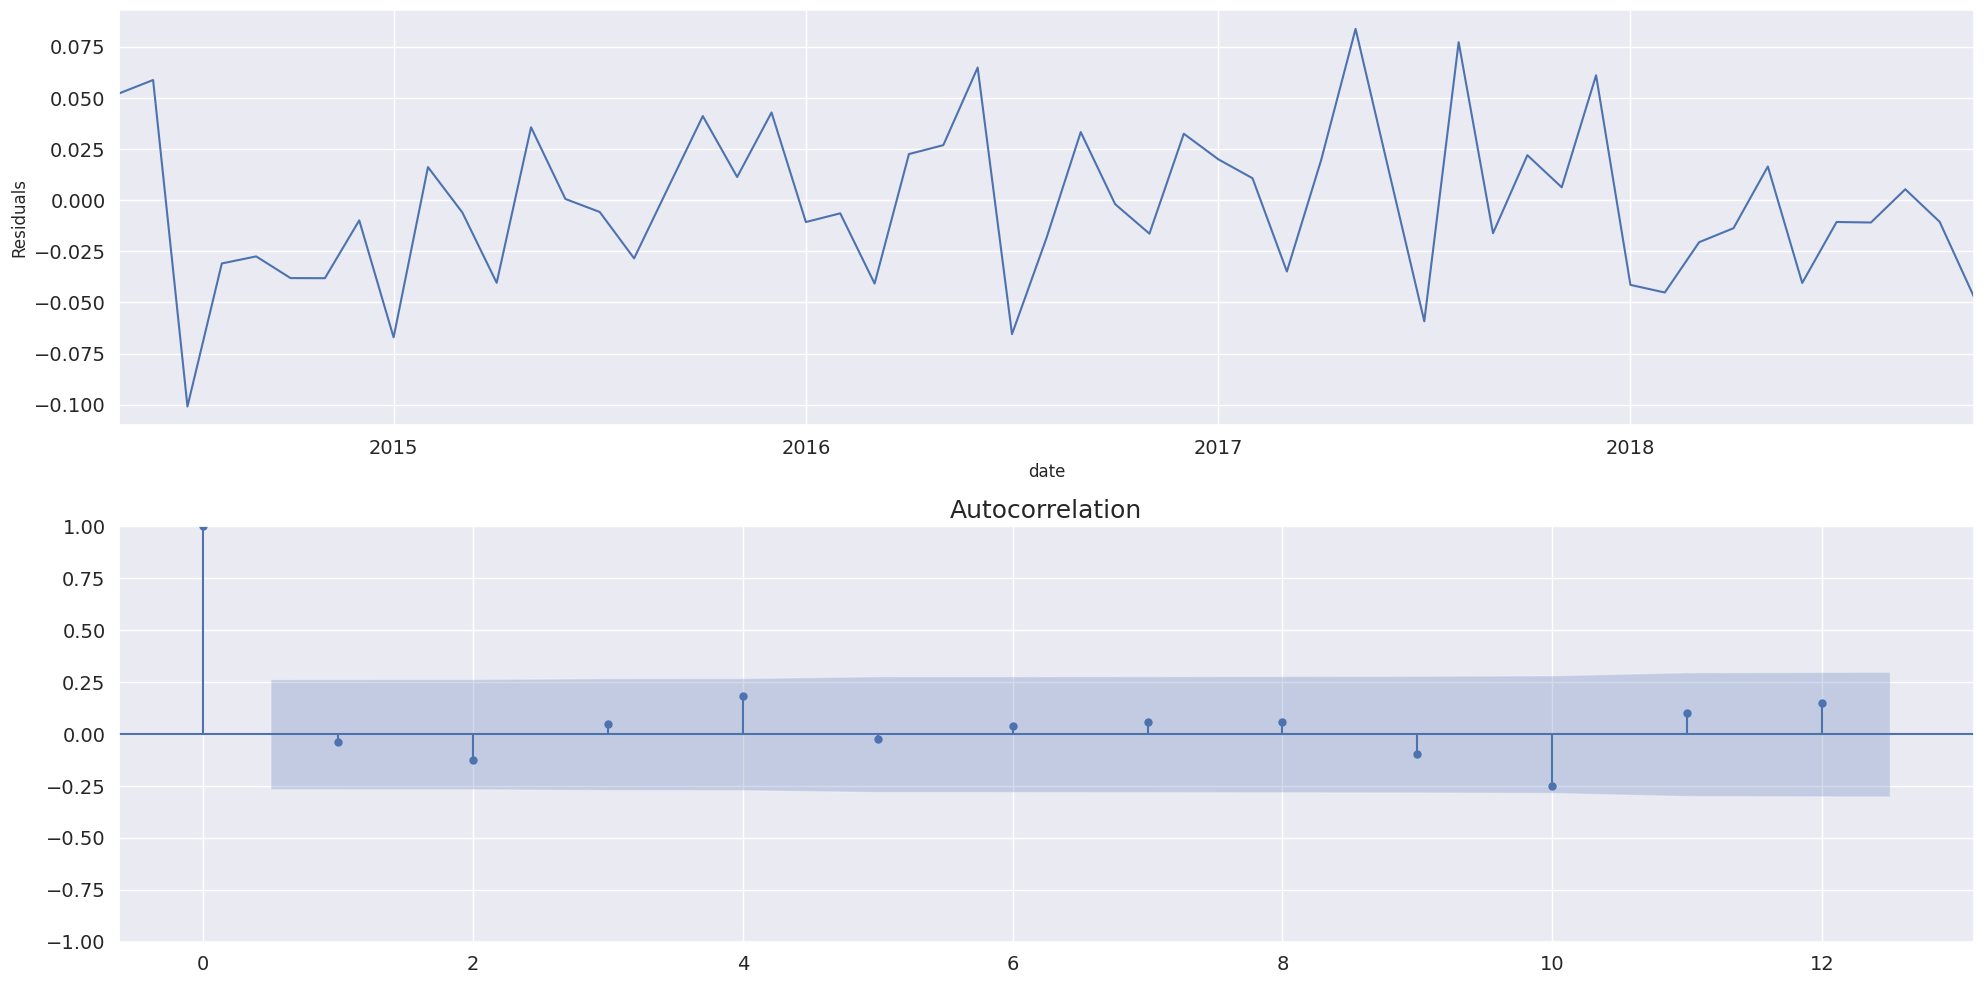

In [ ]:
# STL-decomposition
plt.subplot(211)
best_model.resid[13:].plot()
plt.ylabel(u'Residuals')
ax = plt.subplot(212)
#sm.graphics.tsa.plot_acf(best_model.resid[13:].values.squeeze(), lags=48, ax=ax)
plot_acf(best_model.resid[13:].values.squeeze(), lags=12, ax=ax)

print("Dickey–Fuller test:: p=%f" % adfuller(best_model.resid[13:])[1])

plt.tight_layout()

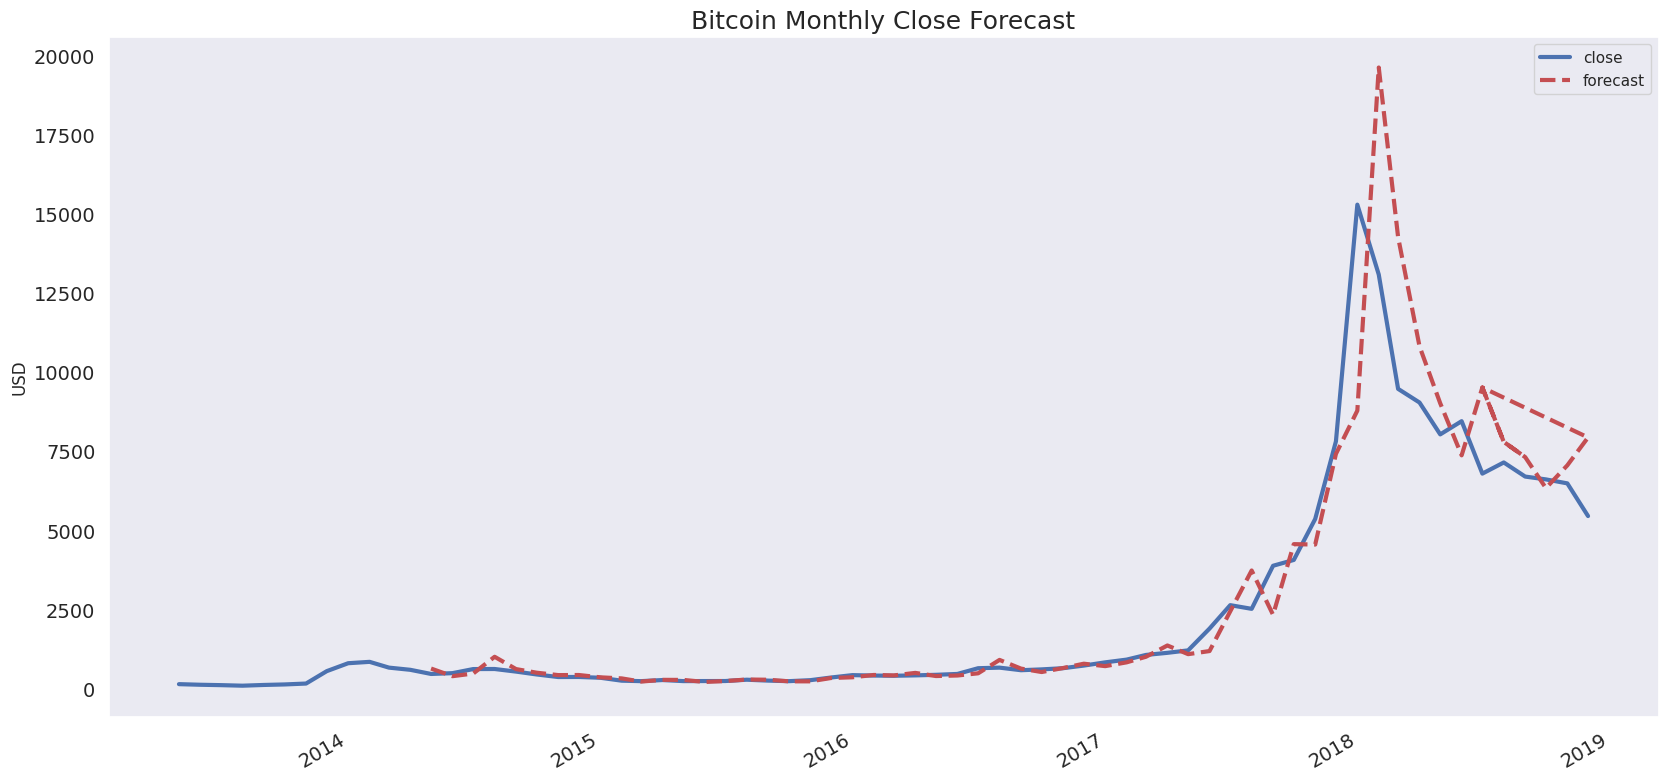

In [ ]:
# Prediction
btc_month_sarima = btc_month[['close']]
date_list = [datetime(2018, 6, 30), datetime(2018, 7, 31), datetime(2018, 8, 31)]
future = pd.DataFrame(index=date_list, columns= btc_month.columns)
btc_month_sarima = pd.concat([btc_month_sarima, future])

btc_month_sarima['forecast'] = invboxcox(best_model.predict(start=12, end=75), lmbda)

btc_month_sarima.close.plot(linewidth=3)
btc_month_sarima.forecast.plot(color='r', ls='--', label='forecast', linewidth=3)
plt.legend()
plt.title('Bitcoin Monthly Close Forecast')
plt.ylabel('USD')
plt.grid()
plt.savefig('bitcoin_monthly_forecast.png')

In [ ]:
btc_month_predict = btc_month['2015-01-01':'2017-01-01']

# Get a naive forecast
close_history = [x for x in btc_month_predict['close']]
predictions = list()
for i in range(len(btc_month_predict)):
    # predict
    predictions.append(close_history[-1])
    # update observation
    close_history.append(btc_month_predict.iloc[i]['close'])

# Calculate RMSE
rmse = sqrt(mean_squared_error(btc_month_predict['close'], predictions))
print('RMSE: %.2f' % rmse)

RMSE: 131.54


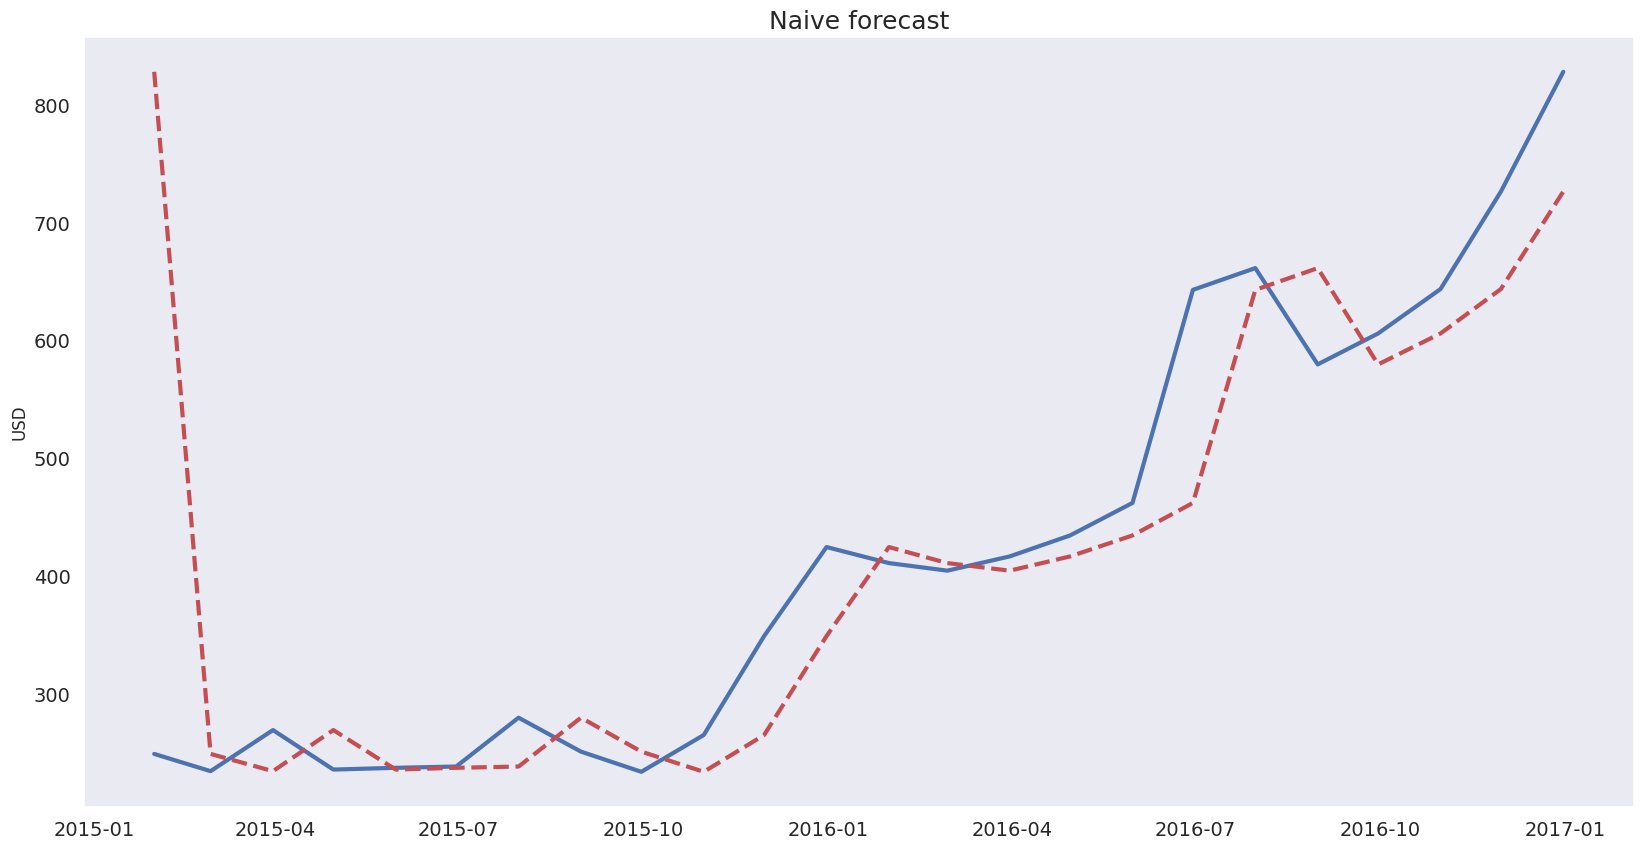

In [ ]:
# Plot predictions vs actual
btc_month_predict['naive_forecast'] = predictions
plt.plot(btc_month_predict['close'],  linewidth=3)
plt.plot(btc_month_predict['naive_forecast'], color='r', ls='--', label='forecast', linewidth=3)
plt.title('Naive forecast')
plt.ylabel('USD')
plt.grid()

In [ ]:
btc_month_sarima = btc_month_sarima.sort_index()


In [ ]:
y_forecasted = btc_month_sarima.forecast
y_truth = btc_month_sarima['2015-01-01':'2017-01-01'].close

# Compute the root mean square error
rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print('Mean Squared Error: {}'.format(round(rmse, 2)))

Mean Squared Error: 75.83


Text(0, 0.5, 'USD')

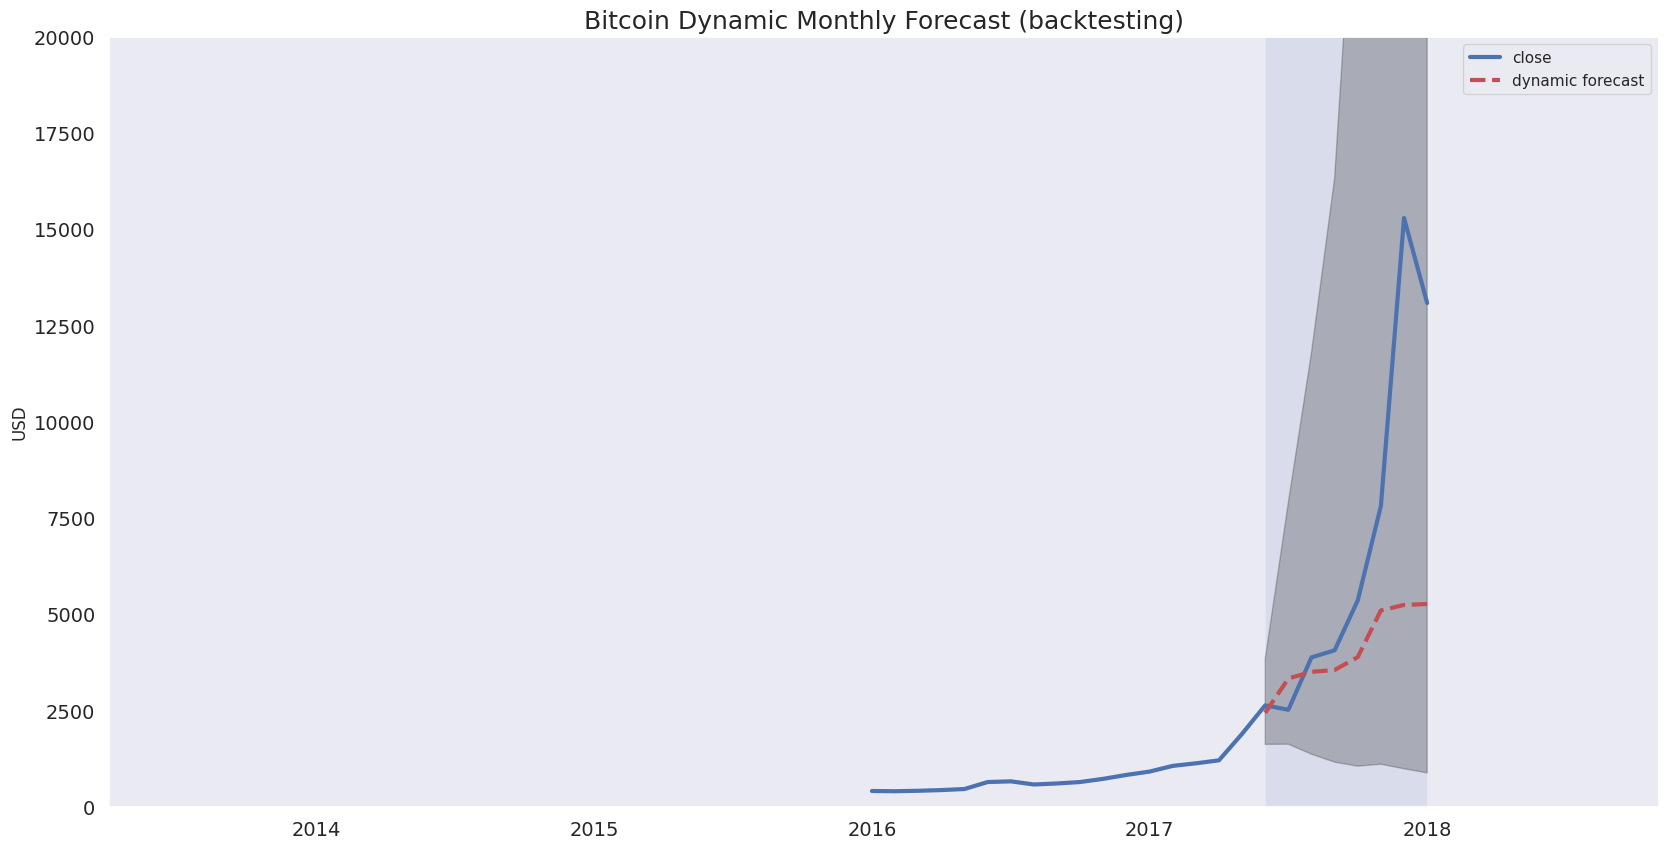

In [ ]:
# Get the dynamic forecast between dates t1 and t2
t1 = pd.to_datetime('2017-06-30')
t2 = pd.to_datetime('2018-01-31')
btc_month_dynamic = best_model.get_prediction(start=t1, end=t2, dynamic=True, full_results=True)
btc_month_sarima['dynamic_forecast'] = invboxcox(btc_month_dynamic.predicted_mean, lmbda)

# Taking 80% confidence interval because the 95% blows out too high to visualise
pred_dynamic_ci = btc_month_dynamic.conf_int(alpha=0.2)
pred_dynamic_ci['lower close_box'] = invboxcox(pred_dynamic_ci['lower close_box'], lmbda)
pred_dynamic_ci['upper close_box'] = invboxcox(pred_dynamic_ci['upper close_box'], lmbda)

# Plot
plt.ylim((0,20000))

btc_month_sarima.close['2016':'2018-01'].plot(label='close', linewidth=3)
btc_month_sarima.dynamic_forecast.plot(color='r', ls='--', label='dynamic forecast', linewidth=3)

plt.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)
plt.fill_betweenx(plt.ylim(), t1, t2, alpha=.1, zorder=-1)

plt.legend()
plt.title('Bitcoin Dynamic Monthly Forecast (backtesting)')
plt.grid()
plt.ylabel('USD')

Text(0, 0.5, 'USD')

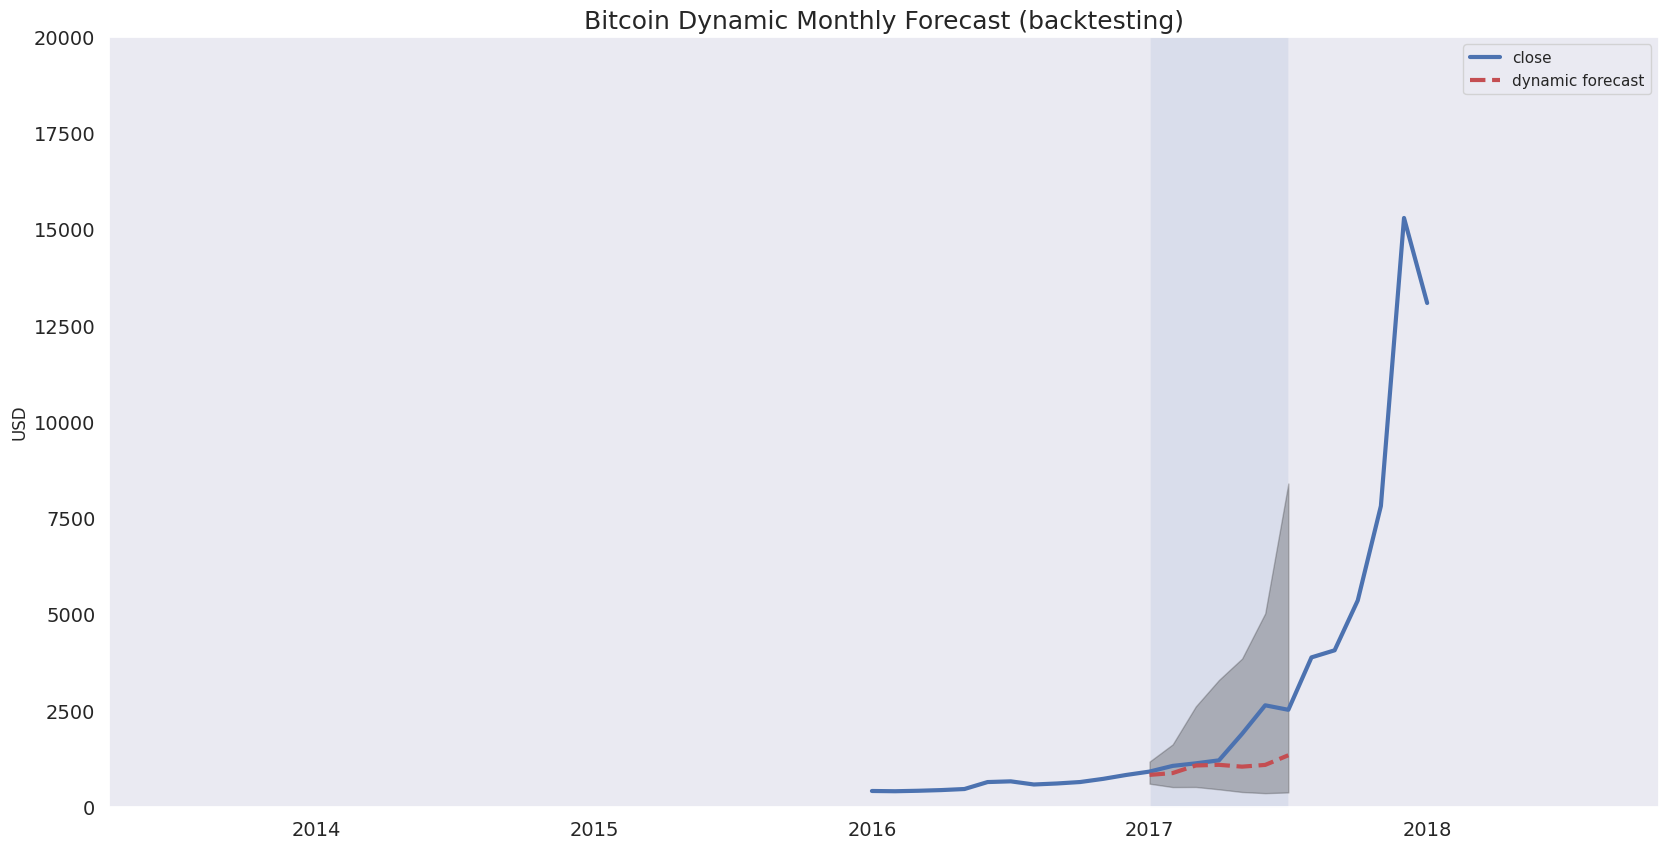

In [ ]:
# Get the dynamic forecast between dates t1 and t2
t1 = pd.to_datetime('2017-01-31')
t2 = pd.to_datetime('2017-07-31')
btc_month_dynamic = best_model.get_prediction(start=t1, end=t2, dynamic=True, full_results=True)
btc_month_sarima['dynamic_forecast'] = invboxcox(btc_month_dynamic.predicted_mean, lmbda)

# Taking 80% confidence interval because the 95% blows out too high to visualise
pred_dynamic_ci = btc_month_dynamic.conf_int(alpha=0.2)
pred_dynamic_ci['lower close_box'] = invboxcox(pred_dynamic_ci['lower close_box'], lmbda)
pred_dynamic_ci['upper close_box'] = invboxcox(pred_dynamic_ci['upper close_box'], lmbda)

# Plot
plt.ylim((0,20000))

btc_month_sarima.close['2016':'2018-01'].plot(label='close', linewidth=3)
btc_month_sarima.dynamic_forecast.plot(color='r', ls='--', label='dynamic forecast', linewidth=3)

plt.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:, 0],
                pred_dynamic_ci.iloc[:, 1], color='k', alpha=.25)
plt.fill_betweenx(plt.ylim(), t1, t2, alpha=.1, zorder=-1)

plt.legend()
plt.title('Bitcoin Dynamic Monthly Forecast (backtesting)')
plt.grid()
plt.ylabel('USD')